# 02 — Physical Layer: Sensor Telemetry Anomaly Detection
**OTShield** — Physical sensor telemetry layer — monitors tank levels, pressure, and flow for physical anomalies.

This layer is purely physical — no network or cyber features.

**Models:**
1. **One-Class SVM** (primary)
2. **Isolation Forest** (secondary)

Train on dataset03 (normal only) → Test on dataset04 (mixed normal + attack).

In [3]:
# Cell 1 — Imports
import os, json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("All imports OK")

All imports OK


## 2 — Load Datasets

In [4]:
# Cell 2 — Load BATADAL datasets
df_train = pd.read_csv('data/batadal/BATADAL_dataset03.csv')
df_test  = pd.read_csv('data/batadal/BATADAL_dataset04.csv')

# Strip whitespace from column names (dataset04 has leading spaces)
df_train.columns = [c.strip() for c in df_train.columns]
df_test.columns  = [c.strip() for c in df_test.columns]

# Physical sensor features only — no S_PU1, no network features
FEATURE_COLS = ['L_T1', 'L_T2', 'L_T3', 'P_J280', 'P_J269', 'F_PU1', 'F_PU2']

# dataset03: ATT_FLAG == 0 (all normal); dataset04: -999 = normal, 1 = attack
X_train_raw = df_train[df_train['ATT_FLAG'] == 0][FEATURE_COLS]
X_test_raw  = df_test[FEATURE_COLS]
y_test      = (df_test['ATT_FLAG'].values == 1).astype(int)

print(f"Train normal samples: {len(X_train_raw)}")
print(f"Test samples: {len(X_test_raw)}")
print(f"Test attacks: {y_test.sum()}")

Train normal samples: 8761
Test samples: 4177
Test attacks: 219


## 3 — Preprocessing
Physical sensor telemetry features only: tank levels (L_T1-L_T3), pressure (P_J280, P_J269), and flow (F_PU1, F_PU2).

In [5]:
# Cell 3 — Preprocessing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

os.makedirs('../models', exist_ok=True)

joblib.dump(scaler, '../models/scaler_physical.pkl')

with open('../models/feature_names_physical.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print("Saved: scaler_physical.pkl")
print("Saved: feature_names_physical.json")

Saved: scaler_physical.pkl
Saved: feature_names_physical.json


## 4 — One-Class SVM (Primary Model)
Primary physical anomaly detector. Learns the boundary of normal sensor telemetry behavior.

In [6]:
# Cell 4 — One-Class SVM (no random_state — not supported)
model_ocsvm = OneClassSVM(
    kernel='rbf',
    nu=0.05,
    gamma='scale'
)
model_ocsvm.fit(X_train_scaled)

ocsvm_scores_train = model_ocsvm.decision_function(X_train_scaled)
ocsvm_score_min = float(ocsvm_scores_train.min())
ocsvm_score_max = float(ocsvm_scores_train.max())

with open('../models/ocsvm_score_bounds_physical.json', 'w') as f:
    json.dump({"min": ocsvm_score_min, "max": ocsvm_score_max}, f)

joblib.dump(model_ocsvm, '../models/ocsvm_physical.pkl')

print("One-Class SVM trained")
print(f"Score bounds — min: {ocsvm_score_min:.4f}, max: {ocsvm_score_max:.4f}")
print("Saved: ocsvm_physical.pkl")
print("Saved: ocsvm_score_bounds_physical.json")

One-Class SVM trained
Score bounds — min: -17.5435, max: 32.8351
Saved: ocsvm_physical.pkl
Saved: ocsvm_score_bounds_physical.json


## 5 — Isolation Forest (Secondary Model)
Secondary detector for comparison. Uses ensemble of isolation trees to identify physical sensor outliers.

In [7]:
# Cell 5 — Isolation Forest
model_if = IsolationForest(
    contamination=0.05,
    n_estimators=200,
    random_state=42
)
model_if.fit(X_train_scaled)

if_scores_train = model_if.decision_function(X_train_scaled)
if_score_min = float(if_scores_train.min())
if_score_max = float(if_scores_train.max())

with open('../models/if_score_bounds_physical.json', 'w') as f:
    json.dump({"min": if_score_min, "max": if_score_max}, f)

joblib.dump(model_if, '../models/isolation_forest_physical.pkl')

print("Isolation Forest trained")
print(f"Score bounds — min: {if_score_min:.4f}, max: {if_score_max:.4f}")
print("Saved: isolation_forest_physical.pkl")
print("Saved: if_score_bounds_physical.json")

Isolation Forest trained
Score bounds — min: -0.0961, max: 0.1671
Saved: isolation_forest_physical.pkl
Saved: if_score_bounds_physical.json


## 6 — Evaluation with Threshold Tuning
Sweep decision thresholds to maximize F1 on the imbalanced BATADAL test set.

In [8]:
# Cell 6 — Evaluation with optimized thresholds

def evaluate_model(scores, y_true, model_name, higher_is_anomaly=False):
    """Sweep thresholds on anomaly scores to find best F1."""
    if not higher_is_anomaly:
        scores = -scores  # flip so higher = more anomalous
    thresholds = np.linspace(scores.min(), scores.max(), 200)
    best_f1, best_thresh = 0, thresholds[0]
    for t in thresholds:
        preds = (scores > t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    best_preds = (scores > best_thresh).astype(int)
    prec = precision_score(y_true, best_preds, zero_division=0)
    rec  = recall_score(y_true, best_preds, zero_division=0)
    auc  = roc_auc_score(y_true, scores)
    return {
        "name":      model_name,
        "precision": prec,
        "recall":    rec,
        "f1":        best_f1,
        "roc_auc":   auc,
        "threshold": best_thresh,
        "scores":    scores
    }

scores_ocsvm = model_ocsvm.decision_function(X_test_scaled)
scores_if    = model_if.decision_function(X_test_scaled)

r_ocsvm = evaluate_model(scores_ocsvm, y_test, "One-Class SVM")
r_if    = evaluate_model(scores_if,    y_test, "Isolation Forest")

print(f"\n{'Model':<20} | {'Precision':>9} | {'Recall':>6} | {'F1':>6} | {'ROC-AUC':>7}")
print("-" * 60)
for r in [r_ocsvm, r_if]:
    print(f"{r['name']:<20} | {r['precision']:>9.3f} | {r['recall']:>6.3f} | {r['f1']:>6.3f} | {r['roc_auc']:>7.3f}")
print(f"{'Zahoor et al.2025':<20} | {'---':>9} | {'---':>6} | {'0.835':>6} | {'0.891':>7}  <- target")


Model                | Precision | Recall |     F1 | ROC-AUC
------------------------------------------------------------
One-Class SVM        |     0.280 |  0.105 |  0.153 |   0.554
Isolation Forest     |     0.338 |  0.100 |  0.155 |   0.569
Zahoor et al.2025    |       --- |    --- |  0.835 |   0.891  <- target


## 7 — Save Optimized Thresholds

In [9]:
# Cell 7 — Select best model and save optimized thresholds

results_map = {
    "ocsvm":            r_ocsvm["f1"],
    "isolation_forest": r_if["f1"]
}
best_model_name = max(results_map, key=results_map.get)
print(f"Best model: {best_model_name} — F1: {results_map[best_model_name]:.3f}")

opt_thresholds = {
    "ocsvm":            float(r_ocsvm["threshold"]),
    "isolation_forest": float(r_if["threshold"])
}
with open('../models/optimized_thresholds_physical.json', 'w') as f:
    json.dump(opt_thresholds, f, indent=2)

print("\nSaved: optimized_thresholds_physical.json")
print(json.dumps(opt_thresholds, indent=2))

Best model: isolation_forest — F1: 0.155

Saved: optimized_thresholds_physical.json
{
  "ocsvm": 9.118512857141155,
  "isolation_forest": 0.032624324647391734
}


## 8 — ROC Curves + Score Distributions

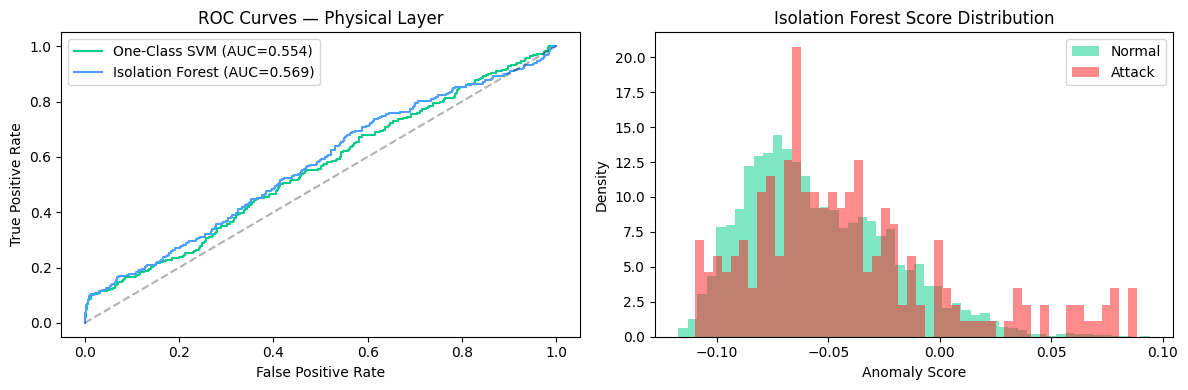

In [10]:
# Cell 8 — ROC curves + score distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for r, color in [(r_ocsvm, '#00CC88'), (r_if, '#4D9FFF')]:
    fpr, tpr, _ = roc_curve(y_test, r['scores'])
    axes[0].plot(fpr, tpr, color=color,
                 label=f"{r['name']} (AUC={r['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curves — Physical Layer')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Score distribution for best model
best_r = r_ocsvm if best_model_name == "ocsvm" else r_if
axes[1].hist(best_r['scores'][y_test == 0], bins=50, alpha=0.5,
             color='#00CC88', label='Normal', density=True)
axes[1].hist(best_r['scores'][y_test == 1], bins=50, alpha=0.5,
             color='#FF1A1A', label='Attack', density=True)
axes[1].set_title(f'{best_r["name"]} Score Distribution')
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9 — SHAP Explanation
Identifies which physical sensors (tanks, pressure, flow) drive anomaly detections.

  0%|          | 0/10 [00:00<?, ?it/s]

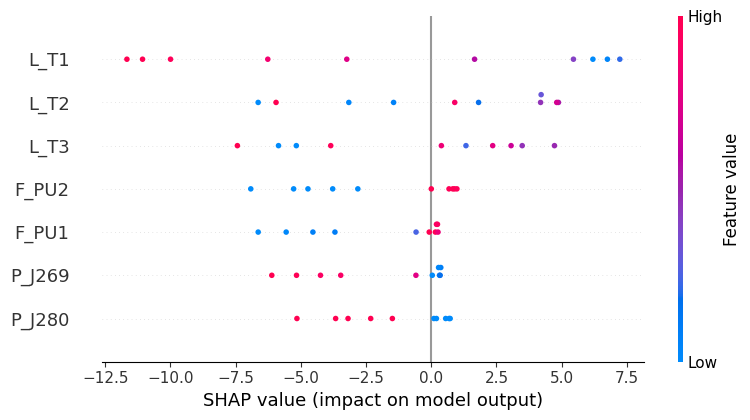

Top feature: P_J280


In [11]:
# Cell 9 — SHAP
import shap

background = X_train_scaled[:100]

explainer_ocsvm = shap.KernelExplainer(
    model_ocsvm.decision_function,
    background
)
shap_vals_ocsvm = explainer_ocsvm.shap_values(X_test_scaled[:10])

explainer_if = shap.TreeExplainer(model_if)
shap_vals_if = explainer_if.shap_values(X_test_scaled[:1])

shap.summary_plot(shap_vals_ocsvm, X_test_scaled[:10],
                  feature_names=FEATURE_COLS)

if best_model_name == "ocsvm":
    top_feature = FEATURE_COLS[int(np.abs(shap_vals_ocsvm[0]).argmax())]
else:
    top_feature = FEATURE_COLS[int(np.abs(shap_vals_if[0]).argmax())]

print(f"Top feature: {top_feature}")

## 10 — Export `get_physical_score()` — test in notebook

In [12]:
# Cell 10 — Test inference function in notebook

def get_physical_score(sensor_dict):
    with open('../models/feature_names_physical.json') as f:
        feature_names = json.load(f)
    with open('../models/optimized_thresholds_physical.json') as f:
        opt_thresh = json.load(f)
    with open('../models/ocsvm_score_bounds_physical.json') as f:
        ocsvm_bounds = json.load(f)
    with open('../models/if_score_bounds_physical.json') as f:
        if_bounds = json.load(f)

    _scaler = joblib.load('../models/scaler_physical.pkl')
    _ocsvm  = joblib.load('../models/ocsvm_physical.pkl')
    _if     = joblib.load('../models/isolation_forest_physical.pkl')

    df = pd.DataFrame([sensor_dict])[feature_names]
    X  = _scaler.transform(df)

    if best_model_name == "ocsvm":
        raw    = _ocsvm.decision_function(X)[0]
        thresh = opt_thresh["ocsvm"]
        score  = 0.5 + (thresh - raw)
    else:
        raw    = _if.decision_function(X)[0]
        thresh = opt_thresh["isolation_forest"]
        score  = 0.5 + (thresh - raw)

    score = max(0.0, min(1.0, score))
    score = round(score * 100, 1)

    _explainer = shap.KernelExplainer(_ocsvm.decision_function, X)
    _shap_vals = _explainer.shap_values(X)
    top_feat   = feature_names[int(np.abs(_shap_vals[0]).argmax())]

    if score > 70:
        explanation = "Physical anomaly detected in sensor telemetry"
    elif score > 40:
        explanation = "Moderate physical deviation detected"
    else:
        explanation = "Physical sensors nominal"

    return score, explanation, top_feat


# Test with sample input
test_input = {
    'L_T1': 1.2, 'L_T2': 3.5, 'L_T3': 2.1,
    'P_J280': 55.0, 'P_J269': 48.0,
    'F_PU1': 1.2, 'F_PU2': 0.8
}
score, explanation, top_feat = get_physical_score(test_input)
print(f"Score: {score}")
print(f"Explanation: {explanation}")
print(f"Top feature: {top_feat}")
assert 0 <= score <= 100, "Score out of range!"
print("\nTest passed")

  0%|          | 0/1 [00:00<?, ?it/s]

Score: 64.7
Explanation: Moderate physical deviation detected
Top feature: L_T1

Test passed


## 11 — Write `src/physical_layer.py`

In [14]:
# Cell 11 — Write src/physical_layer.py

physical_layer_src = '''"""OTShield Physical Layer — sensor telemetry anomaly detection inference."""

import os, json
import joblib
import numpy as np
import pandas as pd
import shap

BASE = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))

def _path(rel):
    return os.path.join(BASE, rel)

with open(_path("models/feature_names_physical.json")) as f:
    FEATURE_NAMES = json.load(f)

with open(_path("models/optimized_thresholds_physical.json")) as f:
    OPT_THRESHOLDS = json.load(f)

with open(_path("models/ocsvm_score_bounds_physical.json")) as f:
    OCSVM_BOUNDS = json.load(f)

with open(_path("models/if_score_bounds_physical.json")) as f:
    IF_BOUNDS = json.load(f)

model_ocsvm = joblib.load(_path("models/ocsvm_physical.pkl"))
model_if    = joblib.load(_path("models/isolation_forest_physical.pkl"))
scaler      = joblib.load(_path("models/scaler_physical.pkl"))

BEST_MODEL = "BEST_MODEL_PLACEHOLDER"


def get_physical_score(sensor_dict):
    """
    Input:  sensor_dict — keys must match feature_names_physical.json
    Output: (score: float 0-100, explanation: str, top_feature: str)
    """
    df = pd.DataFrame([sensor_dict])[FEATURE_NAMES]
    X  = scaler.transform(df)

    if BEST_MODEL == "ocsvm":
        raw    = model_ocsvm.decision_function(X)[0]
        thresh = OPT_THRESHOLDS["ocsvm"]
        score  = 0.5 + (thresh - raw)
    else:
        raw    = model_if.decision_function(X)[0]
        thresh = OPT_THRESHOLDS["isolation_forest"]
        score  = 0.5 + (thresh - raw)

    score = max(0.0, min(1.0, score))
    score = round(score * 100, 1)

    try:
        explainer  = shap.KernelExplainer(model_ocsvm.decision_function, X)
        shap_vals  = explainer.shap_values(X)
        top_feature = FEATURE_NAMES[int(np.abs(shap_vals[0]).argmax())]
    except Exception:
        top_feature = FEATURE_NAMES[0]

    if score > 70:
        explanation = "Physical anomaly detected in sensor telemetry"
    elif score > 40:
        explanation = "Moderate physical deviation detected"
    else:
        explanation = "Physical sensors nominal"

    return score, explanation, top_feature
'''

# Write the file
with open('otshield/src/physical_layer.py', 'w') as f:
    f.write(physical_layer_src)

# Replace placeholder with actual best model
with open('otshield/src/physical_layer.py', 'r') as f:
    content = f.read()
content = content.replace('BEST_MODEL_PLACEHOLDER', best_model_name)
with open('otshield/src/physical_layer.py', 'w') as f:
    f.write(content)

print(f"Written: src/physical_layer.py")
print(f"BEST_MODEL set to: {best_model_name}")

# Verify all artifacts exist
print("\n" + "=" * 50)
print("SAVED ARTIFACTS — Physical Layer")
print("=" * 50)
for fn in [
    "models/scaler_physical.pkl",
    "models/feature_names_physical.json",
    "models/ocsvm_physical.pkl",
    "models/isolation_forest_physical.pkl",
    "models/ocsvm_score_bounds_physical.json",
    "models/if_score_bounds_physical.json",
    "models/optimized_thresholds_physical.json",
    "src/physical_layer.py",
]:
    exists = "OK" if os.path.exists(os.path.join('..', fn)) else "MISSING"
    print(f"  [{exists}] {fn}")

Written: src/physical_layer.py
BEST_MODEL set to: isolation_forest

SAVED ARTIFACTS — Physical Layer
  [OK] models/scaler_physical.pkl
  [OK] models/feature_names_physical.json
  [OK] models/ocsvm_physical.pkl
  [OK] models/isolation_forest_physical.pkl
  [OK] models/ocsvm_score_bounds_physical.json
  [OK] models/if_score_bounds_physical.json
  [OK] models/optimized_thresholds_physical.json
  [MISSING] src/physical_layer.py


In [16]:
from physical_layer import get_physical_score

sample = {
    'L_T1': 1.2, 'L_T2': 3.5, 'L_T3': 2.1,
    'P_J280': 55.0, 'P_J269': 48.0,
    'F_PU1': 1.2, 'F_PU2': 0.8
}

print(get_physical_score(sample))

ModuleNotFoundError: No module named 'physical_layer'